## Plotting routine for global plots

In [49]:
# Imports packages
import matplotlib
matplotlib.use("Agg")

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
import warnings

In [2]:
# Load the data
data_slabctr = xr.open_dataset("LessOzone_Real_Analysis/slabctr_2D_2000-2035.nc")   # Slab control run
data = xr.open_dataset("LessOzone_Real_Analysis/LessOzone_Real_2D_2000-2035.nc")    # Our run
grid = xr.open_dataset("LessOzone_Real_Analysis/icon_grid_G.nc")    # Grid file (necessary for the plot)

# Adjusts the calendar-format of the slab control run
date_floats = data_slabctr["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
data_slabctr = (data_slabctr.assign_coords(time=date_dt))

data_slabctr = data_slabctr.isel(time=slice(1, None))

# Adjusts the calendar-format of our run
date_floats = data["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
data = (data.assign_coords(time=date_dt))

In [44]:
# Variable & Time
VariableName = "tas"
time = "2000-02-01T00:00:00.000000000"
# Please recognize that 2000 is 1989 (11 year shift)

# Labels
title = "2m temperature difference – Feb 2000"
colorbarlabel = "K"

# Design
colormap = "coolwarm"
norm = mcolors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=20) # Only if the colormap is diverging!

In [53]:
# ── T-Test ──────────────────────────────────────────
# Runs over all timesteps; with a defined window size
# Result: p_values_time shape (time, ncells)

window = 1  # window for the rolling mean in months (we want 1)
n_times = len(data.time.values)
n_cells = data[VariableName].shape[1]

p_values_time = np.ones((n_times, n_cells))  # Default: 1 = not significant

for i in range(window, n_times):
    run_window  = data[VariableName].isel(time=slice(i - window, i)).values
    ctrl_window = data_slabctr[VariableName].isel(time=slice(i - window, i)).values
    _, p_values_time[i] = stats.ttest_ind(run_window, ctrl_window, axis=0)

time_idx = np.where(data.time.values == np.datetime64(time))[0][0]
not_significant = p_values_time[time_idx] >= 0.05

/Users/eliasertschnig/Desktop/Uni/Meteorologie/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df


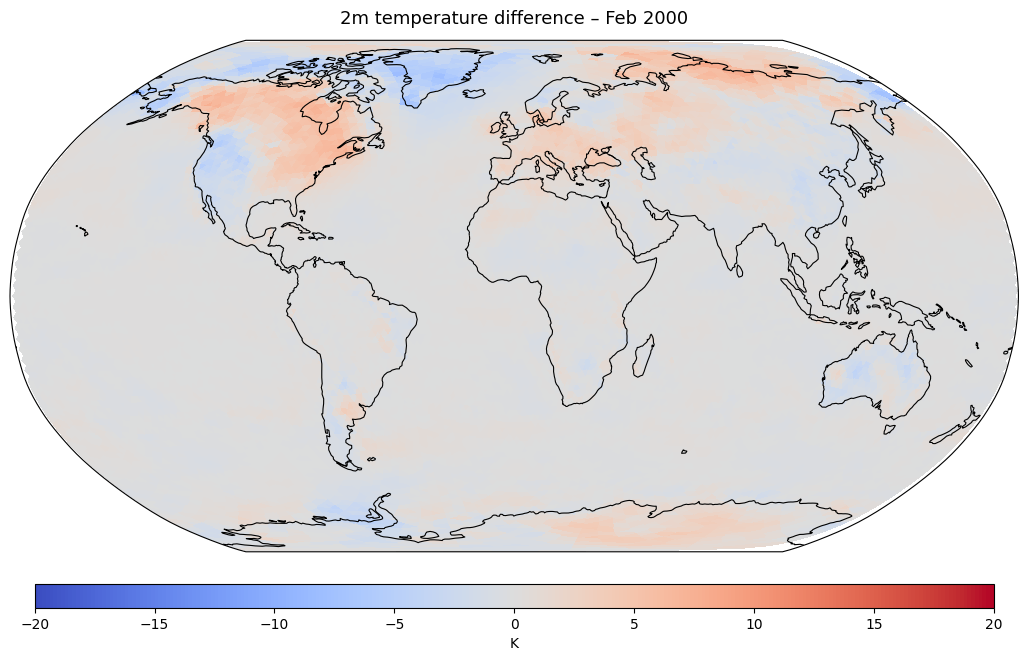

In [45]:
# Adjusts visible variable & time (Change only in cell above!)
values = data[VariableName].sel(time=time).values - data_slabctr[VariableName].sel(time=time).values  # ggf. auch level=0 etc.

# ── Gridpoints (Edges of the triangles) ──────────────────────────────────────
vlon = np.rad2deg(grid["vlon"].values)   # Länge der Vertices
vlat = np.rad2deg(grid["vlat"].values)   # Breite der Vertices

# vertex_of_cell: Shape (3, ncells), 1-based → 0-based
voc = grid["vertex_of_cell"].values - 1  # Shape: (3, ncells)
triangles = voc.T                         # Shape: (ncells, 3)

# ── Triangulation & antimeridian-mask ────────────────────────────────────────
triang = mtri.Triangulation(vlon, vlat, triangles)

x0 = vlon[triangles[:, 0]]
x1 = vlon[triangles[:, 1]]
x2 = vlon[triangles[:, 2]]
bad = (np.abs(x0 - x1) > 180) | (np.abs(x1 - x2) > 180) | (np.abs(x0 - x2) > 180)
triang.set_mask(bad)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(resolution="110m", linewidth=0.8, color="black")
ax.set_title(title, fontsize=13, pad=12)

# Differenz-Plot (alle Zellen)
tc = ax.tripcolor(
    triang,
    values,
    norm=norm,
    cmap=colormap,
    transform=ccrs.PlateCarree(),
    shading="flat",
    rasterized=True,
)

# If marked -> not significant
triang_copy = mtri.Triangulation(vlon, vlat, triangles)
# Mask: hide everything except the not-significant cells
combined_mask = bad.copy()
combined_mask[~not_significant] = True
triang_copy.set_mask(combined_mask)

ax.tripcolor(
    triang_copy,
    np.zeros(len(values)),   # Colour gets overwritten, independent of the value
    cmap="Greys",
    vmin=0, vmax=1,
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    shading="flat",
    rasterized=True,
)

plt.colorbar(
    tc, ax=ax,
    orientation="horizontal",
    pad=0.05,
    aspect=40,
    label=colorbarlabel,
    shrink=0.7,
)

plt.tight_layout()
plt.show()

In [51]:
# --------------------------------------------------------------------------------------------------------------
# Automation for plotting and saving all images for a timespan
# --------------------------------------------------------------------------------------------------------------
warnings.filterwarnings("ignore")

timelist = [f"{year}-02-01T00:00:00.000000000" for year in range(2000, 2035)] # Needs to be adjusted
titlelist = [f"2m temperature difference – {timelist[i][:10]}" for i in range(len(timelist))] # Needs to be adjusted
for i in range(33,35):
    # Adjust the time
    time = timelist[i]

    # ttest
    window = 1
    n_times = len(data.time.values)
    n_cells = data[VariableName].shape[1]

    p_values_time = np.ones((n_times, n_cells))

    for j in range(window, n_times):
        run_window  = data[VariableName].isel(time=slice(j - window, j)).values
        ctrl_window = data_slabctr[VariableName].isel(time=slice(j - window, j)).values
        _, p_values_time[j] = stats.ttest_ind(run_window, ctrl_window, axis=0)

    # Zeitschritt aus dem time-String auswählen (wie im Rest des Codes)
    time_idx = np.where(data.time.values == np.datetime64(time))[0][0]
    not_significant = p_values_time[time_idx] >= 0.05

    # Adjusts visible variable & time (Change only in cell above!)
    values = data[VariableName].sel(time=time).values - data_slabctr[VariableName].sel(time=time).values

    # ── Gridpoints (Edges of the triangles) ──────────────────────────────────────
    vlon = np.rad2deg(grid["vlon"].values)
    vlat = np.rad2deg(grid["vlat"].values)

    # vertex_of_cell: Shape (3, ncells), 1-based → 0-based
    voc = grid["vertex_of_cell"].values - 1
    triangles = voc.T

    # ── Triangulation & antimeridian-mask ────────────────────────────────────────
    triang = mtri.Triangulation(vlon, vlat, triangles)

    x0 = vlon[triangles[:, 0]]
    x1 = vlon[triangles[:, 1]]
    x2 = vlon[triangles[:, 2]]
    bad = (np.abs(x0 - x1) > 180) | (np.abs(x1 - x2) > 180) | (np.abs(x0 - x2) > 180)
    triang.set_mask(bad)

    # ── Plot ───────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.8, color="black")
    ax.set_title(titlelist[i], fontsize=13, pad=12)

    # Difference-plot
    tc = ax.tripcolor(
        triang,
        values,
        norm=norm,
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        shading="flat",
        rasterized=True,
    )

    triang_copy = mtri.Triangulation(vlon, vlat, triangles)
    # Mask: hide everything except the not-significant cells
    combined_mask = bad.copy()
    combined_mask[~not_significant] = True
    triang_copy.set_mask(combined_mask)

    ax.tripcolor(
        triang_copy,
        np.zeros(len(values)),
        cmap="Greys",
        vmin=0, vmax=1,
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        shading="flat",
        rasterized=True,
    )

    plt.colorbar(
        tc, ax=ax,
        orientation="horizontal",
        pad=0.05,
        aspect=40,
        label=colorbarlabel,
        shrink=0.7,
    )

    plt.tight_layout()
    plt.savefig(f"2m_temp_{timelist[i][:10]}.png", dpi=100) # Needs to be adjusted
    plt.close(fig)

warnings.filterwarnings("default")

In [52]:
# --------------------------------------------------------------------------------------------------------------
# OLD CODE BELOW HERE! -----------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------------------

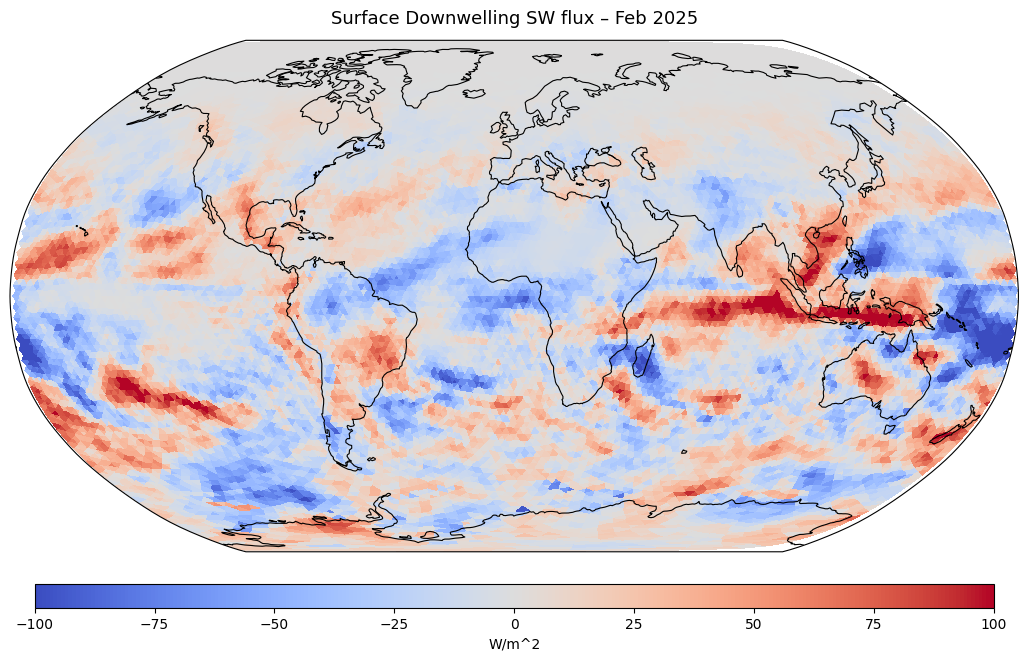

In [7]:
# ── Plot (just without the t-test) ───────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(resolution="110m", linewidth=0.8, color="black")
ax.set_title(title, fontsize=13, pad=12)

tc = ax.tripcolor(
    triang,
    values,
    norm = norm,
    cmap=colormap,
    transform=ccrs.PlateCarree(),
    shading="flat",    # jedes Dreieck einfarbig (= echte ICON-Zellen)
    rasterized=True,   # bessere Performance & saubere Vektorgrafik
)

plt.colorbar(
    tc, ax=ax,
    orientation="horizontal",
    pad=0.05,
    aspect=40,
    label=colorbarlabel,
    shrink=0.7,
)

plt.tight_layout()
#plt.savefig("icon_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
timelist = [f"{year}-02-01T00:00:00.000000000" for year in range(2000, 2035)]
timelist[0][:10]

'2000-02-01'